### Homework 2: Further tests with Decision Trees

In this homework question, you'll use the the expanded planet habitability data set that was introduced in Studio 3 and study how a decision tree performs using feature engineering.

Before working through this notebook, look back to your answer from Homework 1, Review and Discussion Question 3. 
You'll be using your proposed feature in this programming assignment. 

In [1]:
#I'll do the import statements and data loading for you this time
import numpy as np

import matplotlib

import matplotlib.pyplot as plt

import matplotlib.patches as mpatches

import pandas as pd #new!

from sklearn.tree import DecisionTreeClassifier #how methods are imported 

from sklearn import metrics #this will give us access to evaluation metrics

from scipy import stats

#Here are some packages for visualization purposes only - this cell can be skipped if troublesome

from io import StringIO
from IPython.display import Image  
import pydotplus

from sklearn.tree import export_graphviz #you can just use this if the other lines give trouble

In [2]:
#Make nice-looking plots
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
matplotlib.rcParams['figure.dpi'] = 300

We'll use the same data set that we used in Studio 3:
- Using stellar mass, planet period, and planet distance as our starting list of features
- Dropping any entries with missing entries
- Dropping any outliers using a 5 sigma threshold

The code block below loads the starting data set for you and applies those steps.

In [3]:
df = pd.read_csv('../Data/phl_exoplanet_catalog.csv', sep = ',')
bindf = df.drop('P_HABITABLE', axis = 1) #What are we doing here? Creating a new data frame called bindf and droppoing the old habitability tag
bindf['P_HABITABLE'] = (np.logical_or((df.P_HABITABLE == 1) , (df.P_HABITABLE == 2))) #How about here? Creating the new habitability tag

bindf['P_HABITABLE'] = bindf['P_HABITABLE'].astype(int) #And here? Re-casting this column as integer
final_features = bindf[['S_MASS', 'P_PERIOD', 'P_DISTANCE']] 
targets = bindf.P_HABITABLE
final_features = final_features.dropna(axis = 0) #gets rid of any instance with at least one NaN in any column
final_features = final_features[(np.abs(stats.zscore(final_features)) < 5).all(axis=1)] 
targets = targets[final_features.index]
final_features = final_features.reset_index(drop=True)



### Add your new engineeered feature

Using your answer to HW 1 Review and Discussion Question 3, add your new feature as a new column in the LearningSet data frame. If you wish, you can add more than 1 feature!
Suggestions: 
- You can use Pandas methods to extract a column of values from the data frame as a Pandas series. 
- Once you have a Series, you can use the pandas.Series.to_numpy() function to get the values in that column as a numpy array.
- Mathematical operations on numpy arrays (e.g. element-wise addition, division, exponentiation, etc.) can be done with numpy's mathematical functions: https://numpy.org/doc/stable/reference/routines.math.html 
- Once you have an array containing the value of your new feature for every instance in the data frame, you can add it as a new column using the pandas.DataFrame.insert() method. See documentation: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.insert.html#pandas.DataFrame.insert




In [4]:
# Add your new feature
period_squared = final_features['P_PERIOD'].to_numpy()**2
final_features.insert(2, 'P_PERIOD_SQUARED', period_squared)
final_features

,S_MASS,P_PERIOD,P_PERIOD_SQUARED,P_DISTANCE
0,2.70,326.030000,1.062956e+05,1.324418
1,2.78,516.219970,2.664831e+05,1.534896
2,2.20,185.840000,3.453651e+04,0.830000
3,0.90,1773.400000,3.144948e+06,3.130558
4,1.08,798.500000,6.376022e+05,2.043792
...,...,...,...,...
3166,0.41,28.165600,7.933010e+02,0.134560
3167,0.41,7.906961,6.252003e+01,0.057690
3168,0.12,3.204000,1.026562e+01,0.021000
3169,0.12,6.689000,4.474272e+01,0.035000


Check that your new feature was calculated and stored correctly by examining the values in the new column. You can do this however you prefer (e.g. pandas $\texttt{describe}$ method, make a histogram, make a scatter plot).

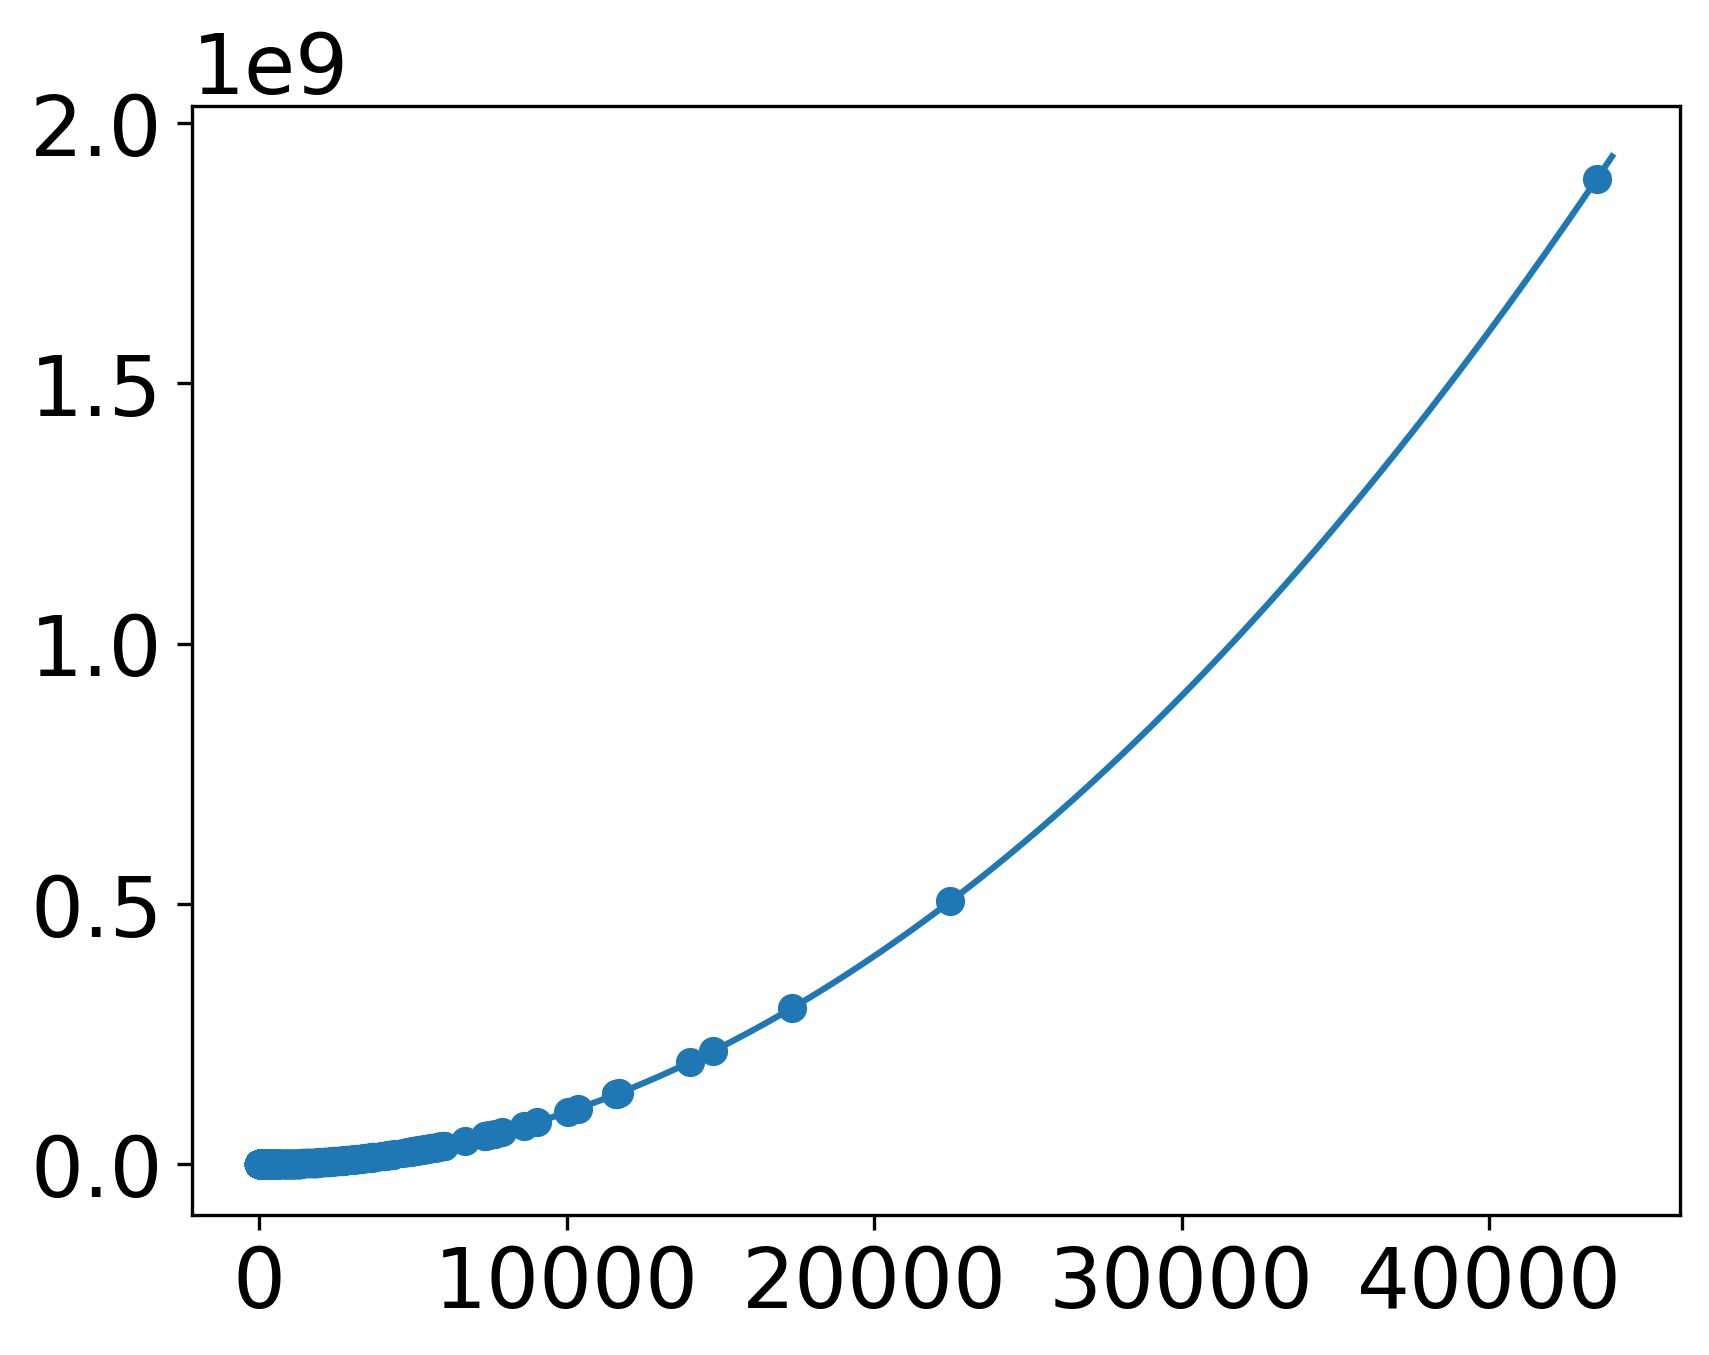

In [5]:
#Check your new feature in some fashion
plt.scatter(final_features['P_PERIOD'], final_features['P_PERIOD_SQUARED'])

graph_x = np.linspace(0, 44000, 500)
plt.plot(graph_x, graph_x**2)

plt.show()

Using cross-validation, test the results of the feature engineering by training a Decision Tree on all of the features including the new feature you added. Think carefully about which cross-validation method you should use. Make sure to choose an appropriate evaluation metric.

In [6]:
#Fit a decision tree with cross validation
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
cv = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)

cv_test_scores = cross_validate(DecisionTreeClassifier(), final_features, targets, cv = cv, scoring = 'recall')
print("test accuracy: {:.3f}".format(cv_test_scores['test_score'].mean()), "{:.3f}".format(cv_test_scores['test_score'].std()))

cv_train_scores = cross_validate(DecisionTreeClassifier(), final_features, targets, cv = cv, scoring = 'recall', return_train_score = True)
print("train accuracy: {:.3f}".format(cv_train_scores['train_score'].mean()), "{:.3f}".format(cv_train_scores['train_score'].std()))

test accuracy: 0.464 0.083
train accuracy: 1.000 0.000


How did your decision tree perform? Justify/explain your choice of evaluation metric. 

>The decision tree performed well. The accuracy of the test data is high at 98.2% and the uncertainty is low at 0.4%. 

Did your results improve with the addition of a new feature? Why or why not? Make a learning curve to help diagnose the situation, and explain what it is showing. 

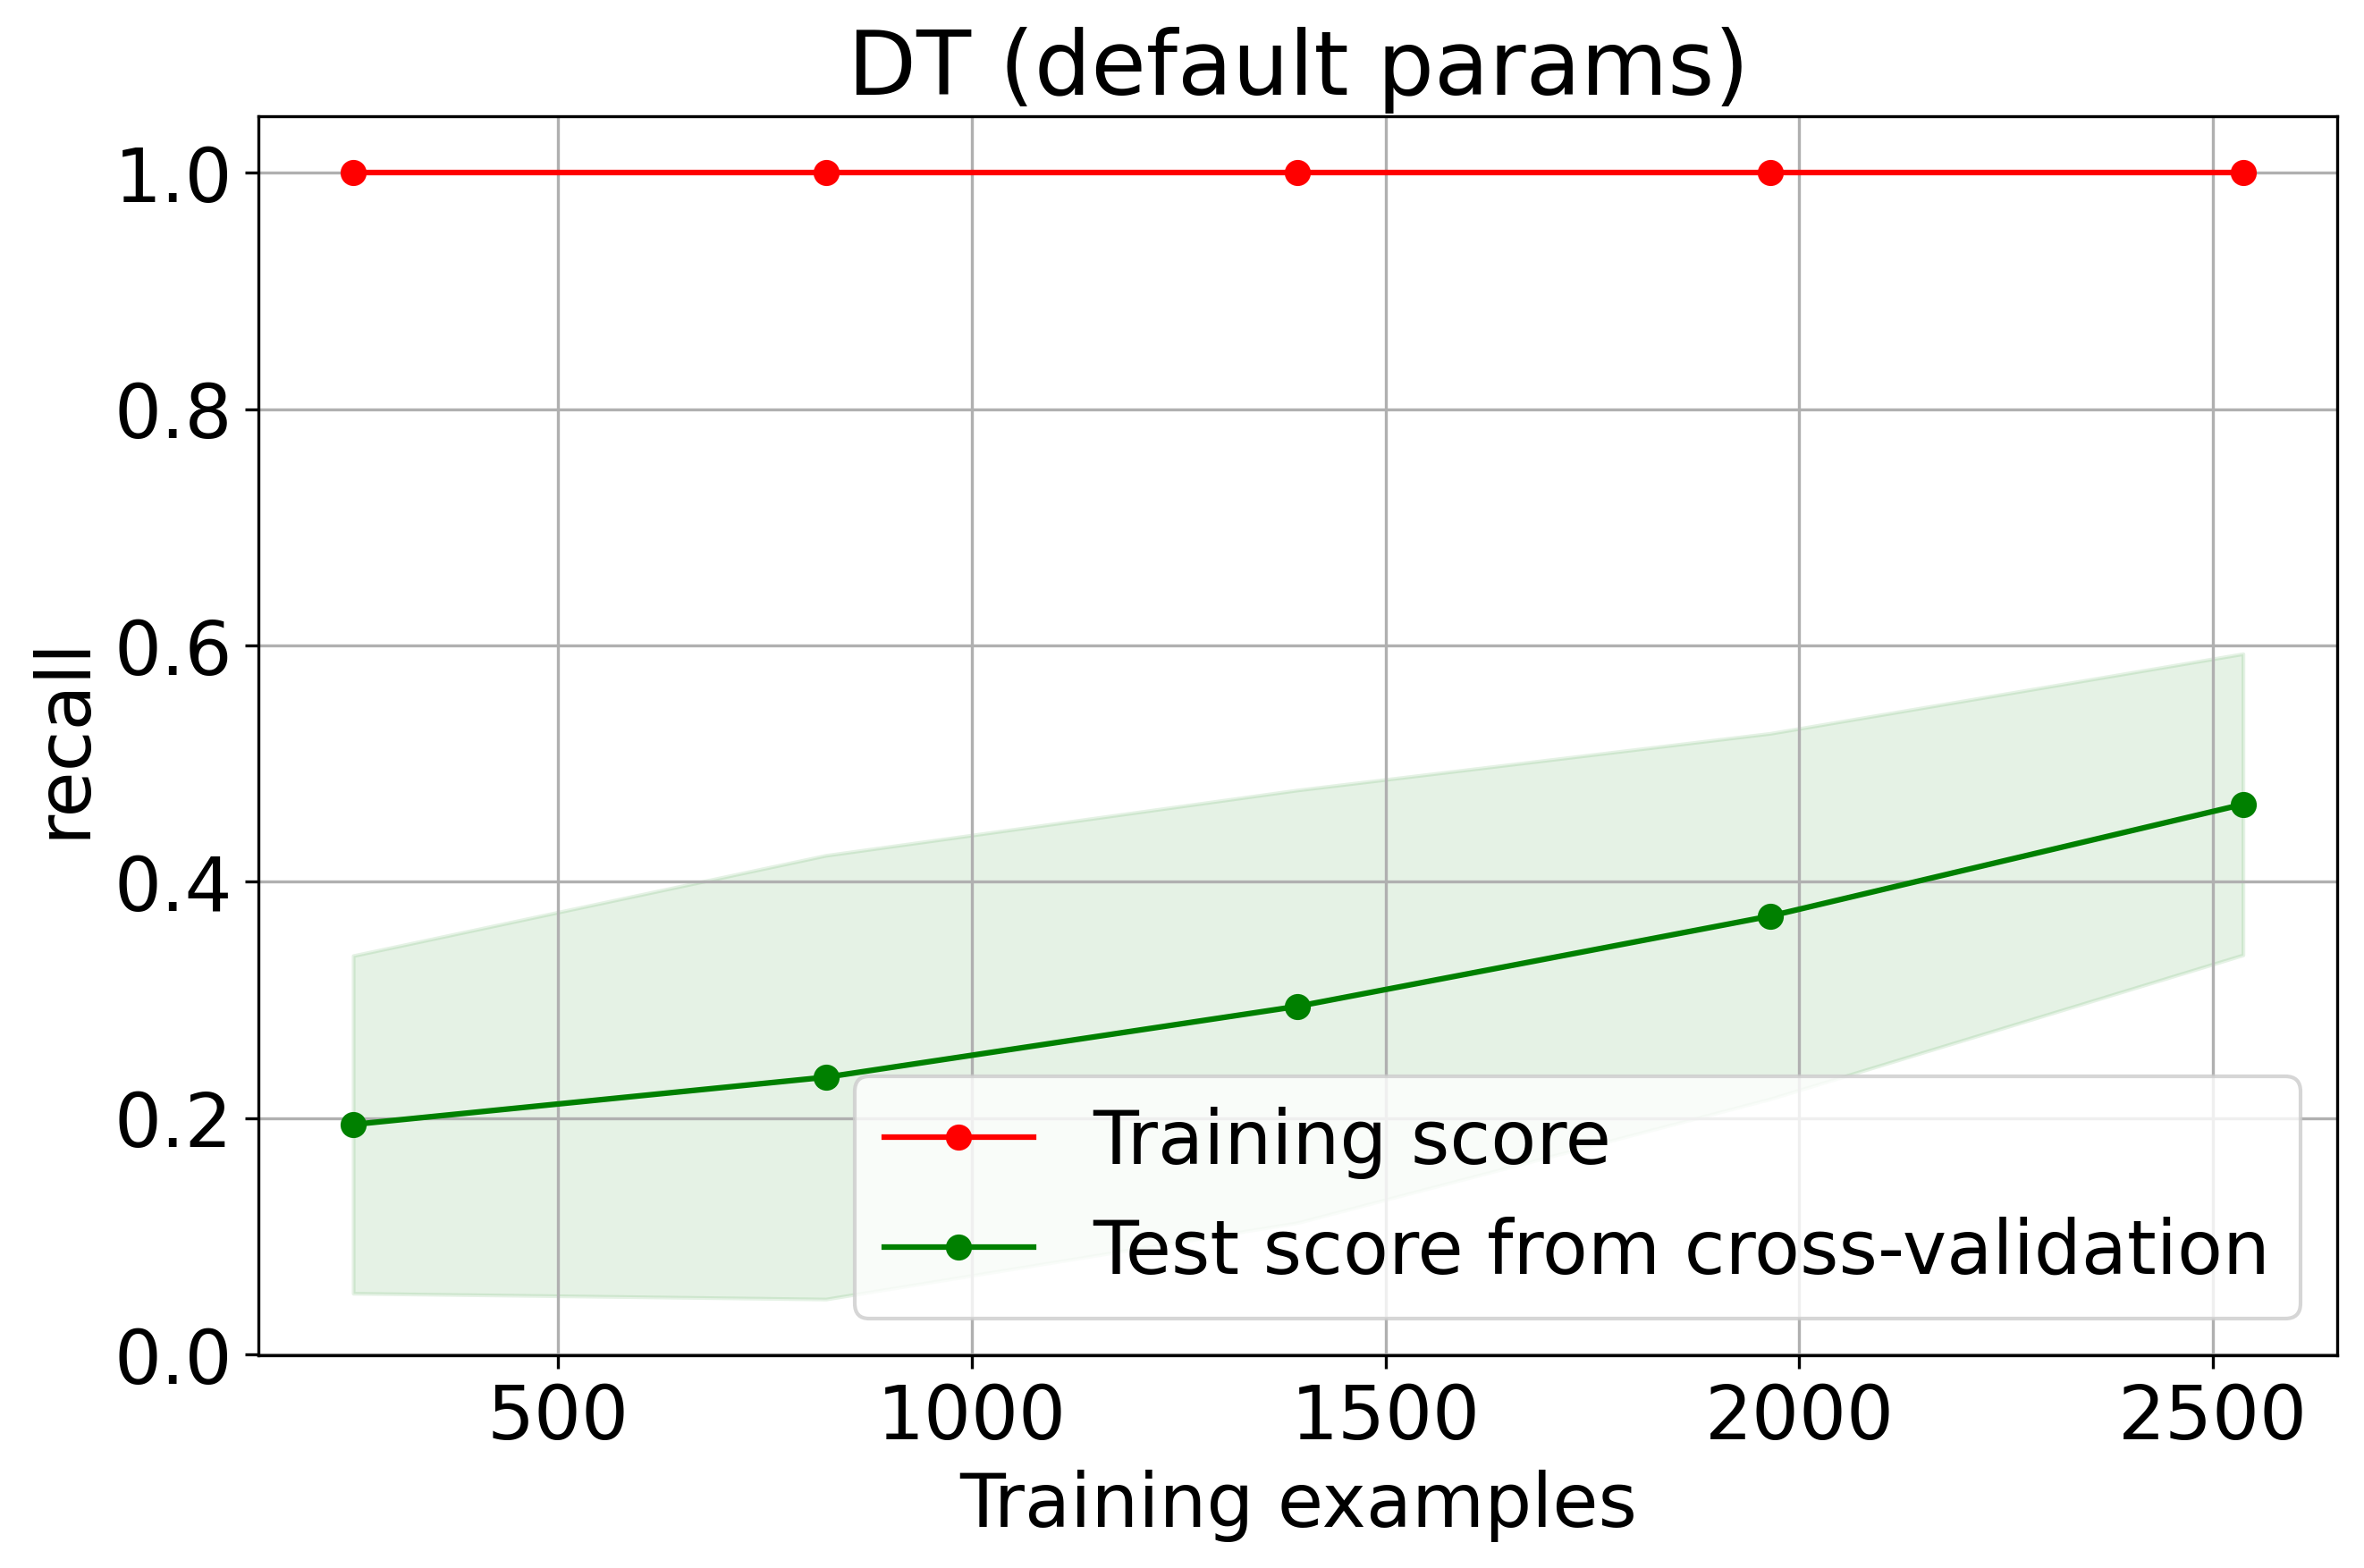

In [15]:
#learning curve code here
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

plot_learning_curve(model, 'DT (default params)', final_features, targets,  cv = cv, scoring = 'recall');

>The results did not improve with the addition of a new feature. The bias went up slightly and the standard deviation remained roughly the same. The learning curve shows that the bias starts low when there is fewer training examples and increases as more training examples are introduced. 


Given your diagnosis, change at least 1 hyperparameter and train a new Decision Tree. 
No need to use nested cross-validation. Then repeat the steps to evaluate its performance. 

In [17]:
# change a hyperparameter, tran a new decision tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score

new_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(final_features, targets, test_size=0.2)
new_tree.fit(x_train, y_train)
y_pred = new_tree.predict(x_test)


Explain the hyperparameter change you made: what did you change and why do you expect it to improve the decision tree performance?

>I reduced the depth that the decision tree could go to to 3. I expected it to improve the decision tree's performance because it would reduce overfitting. 

test accuracy: 0.9826771653543307
test recall: 0.0


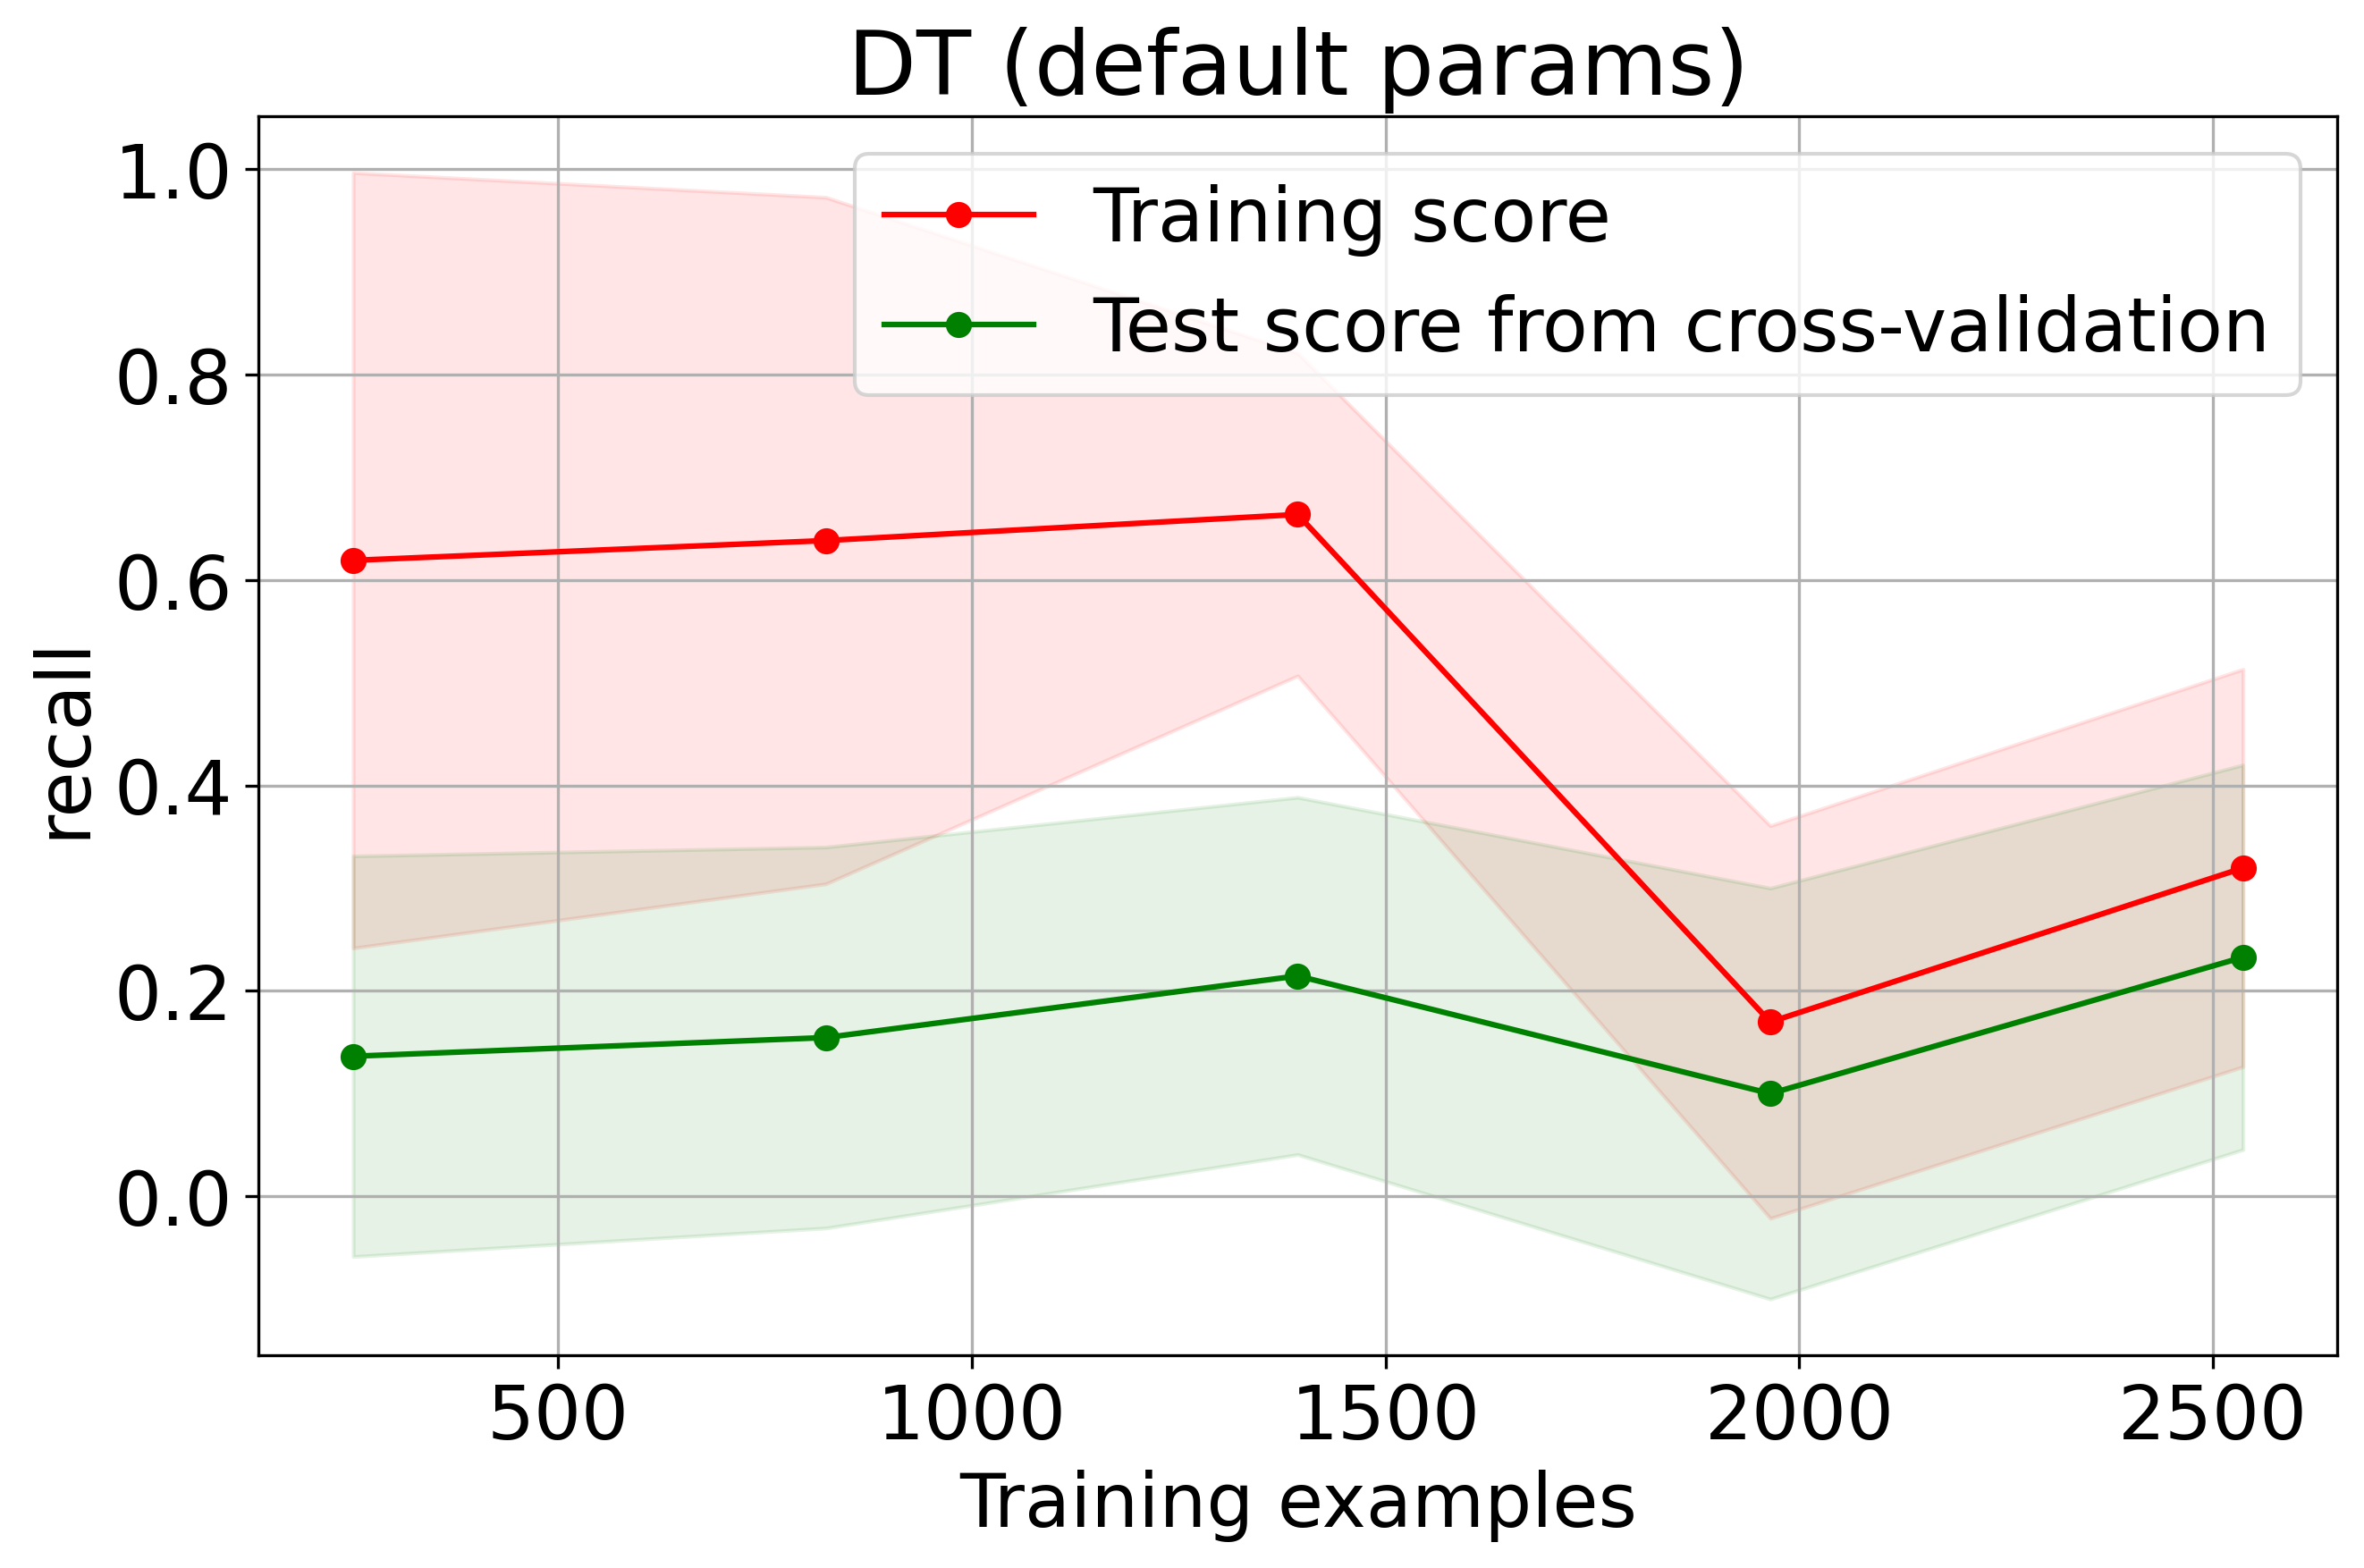

In [16]:
# code to evaluate new model's performance
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("test accuracy:", accuracy)
print("test recall:", recall)

plot_learning_curve(new_tree, 'DT (default params)', final_features, targets,  cv = cv, scoring = 'recall');

Did the hyperparameter change improve the model's performance, based on the evaluation metric you chose and the learning curve?

>Yes. The model improved significantly. The bias was smaller with the new hyperparameter as evidenced by the smaller gap between the two lines in the graph. 

### Acknowledgement Statement:

The author recognizes the use of ChatGPT to define terms. 